In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter 노트북에서 그래프를 셀 아래에 인라인 표시 (이 설정이 없으면 그래프가 안 나옴)
%matplotlib inline

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('pandas/data/california_housing_test.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


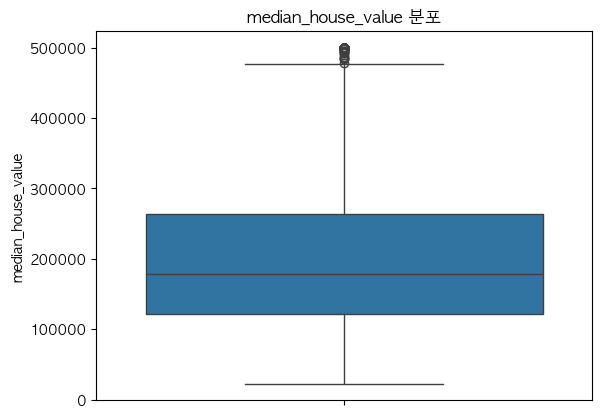

In [19]:
# 단일 변수 boxplot
sns.boxplot(y=df['median_house_value'])
plt.title('median_house_value 분포')
plt.show()

In [20]:
# === IQR(사분위 범위) 방식을 이용한 이상치 탐지 ===
# IQR = Q3 - Q1 이며, Q1 - 1.5*IQR 미만 또는 Q3 + 1.5*IQR 초과인 값을 이상치로 판단

Q1 = df['median_house_value'].quantile(0.25)  # 1사분위수 (25%)
Q3 = df['median_house_value'].quantile(0.75)  # 3사분위수 (75%)
IQR = Q3 - Q1  # 사분위 범위

# 이상치 판단 기준 경계값 계산
lower_bound = Q1 - 1.5 * IQR  # 하한 경계
upper_bound = Q3 + 1.5 * IQR  # 상한 경계

print(f"Q1 (25%): {Q1:,.0f}")
print(f"Q3 (75%): {Q3:,.0f}")
print(f"IQR: {IQR:,.0f}")
print(f"하한 경계: {lower_bound:,.0f}")
print(f"상한 경계: {upper_bound:,.0f}")
print()

# 이상치 필터링: 하한 미만 또는 상한 초과인 데이터를 추출
outliers = df[(df['median_house_value'] < lower_bound) | (df['median_house_value'] > upper_bound)]

print(f"전체 데이터 수: {len(df)}개")
print(f"이상치 데이터 수: {len(outliers)}개")
print(f"이상치 비율: {len(outliers) / len(df) * 100:.2f}%")
print()
print("=== 이상치 데이터 목록 ===")
outliers[['longitude', 'latitude', 'median_income', 'median_house_value']].head(20)

Q1 (25%): 121,200
Q3 (75%): 263,975
IQR: 142,775
하한 경계: -92,962
상한 경계: 478,138

전체 데이터 수: 3000개
이상치 데이터 수: 141개
이상치 비율: 4.70%

=== 이상치 데이터 목록 ===


,longitude,latitude,median_income,median_house_value
25,-118.03,34.16,7.1615,484700.0
42,-118.06,34.15,15.0001,500001.0
117,-122.07,37.34,10.1007,500001.0
118,-117.18,33.02,13.6623,500001.0
128,-122.47,37.79,4.7500,500001.0
135,-122.34,37.56,12.6417,500001.0
161,-117.85,33.62,15.0001,500001.0
185,-118.28,34.02,0.4999,500001.0
219,-117.90,33.60,3.6538,500001.0
280,-118.38,34.14,6.0876,483800.0


## 전체 수치형 변수 이상치 탐지
> `median_house_value` 외에도 이상치가 존재할 수 있는 **모든 수치형 변수**를 박스플롯으로 한눈에 확인하고,  
> 산점도를 통해 변수 간 관계에서 나타나는 이상치 패턴을 파악합니다.

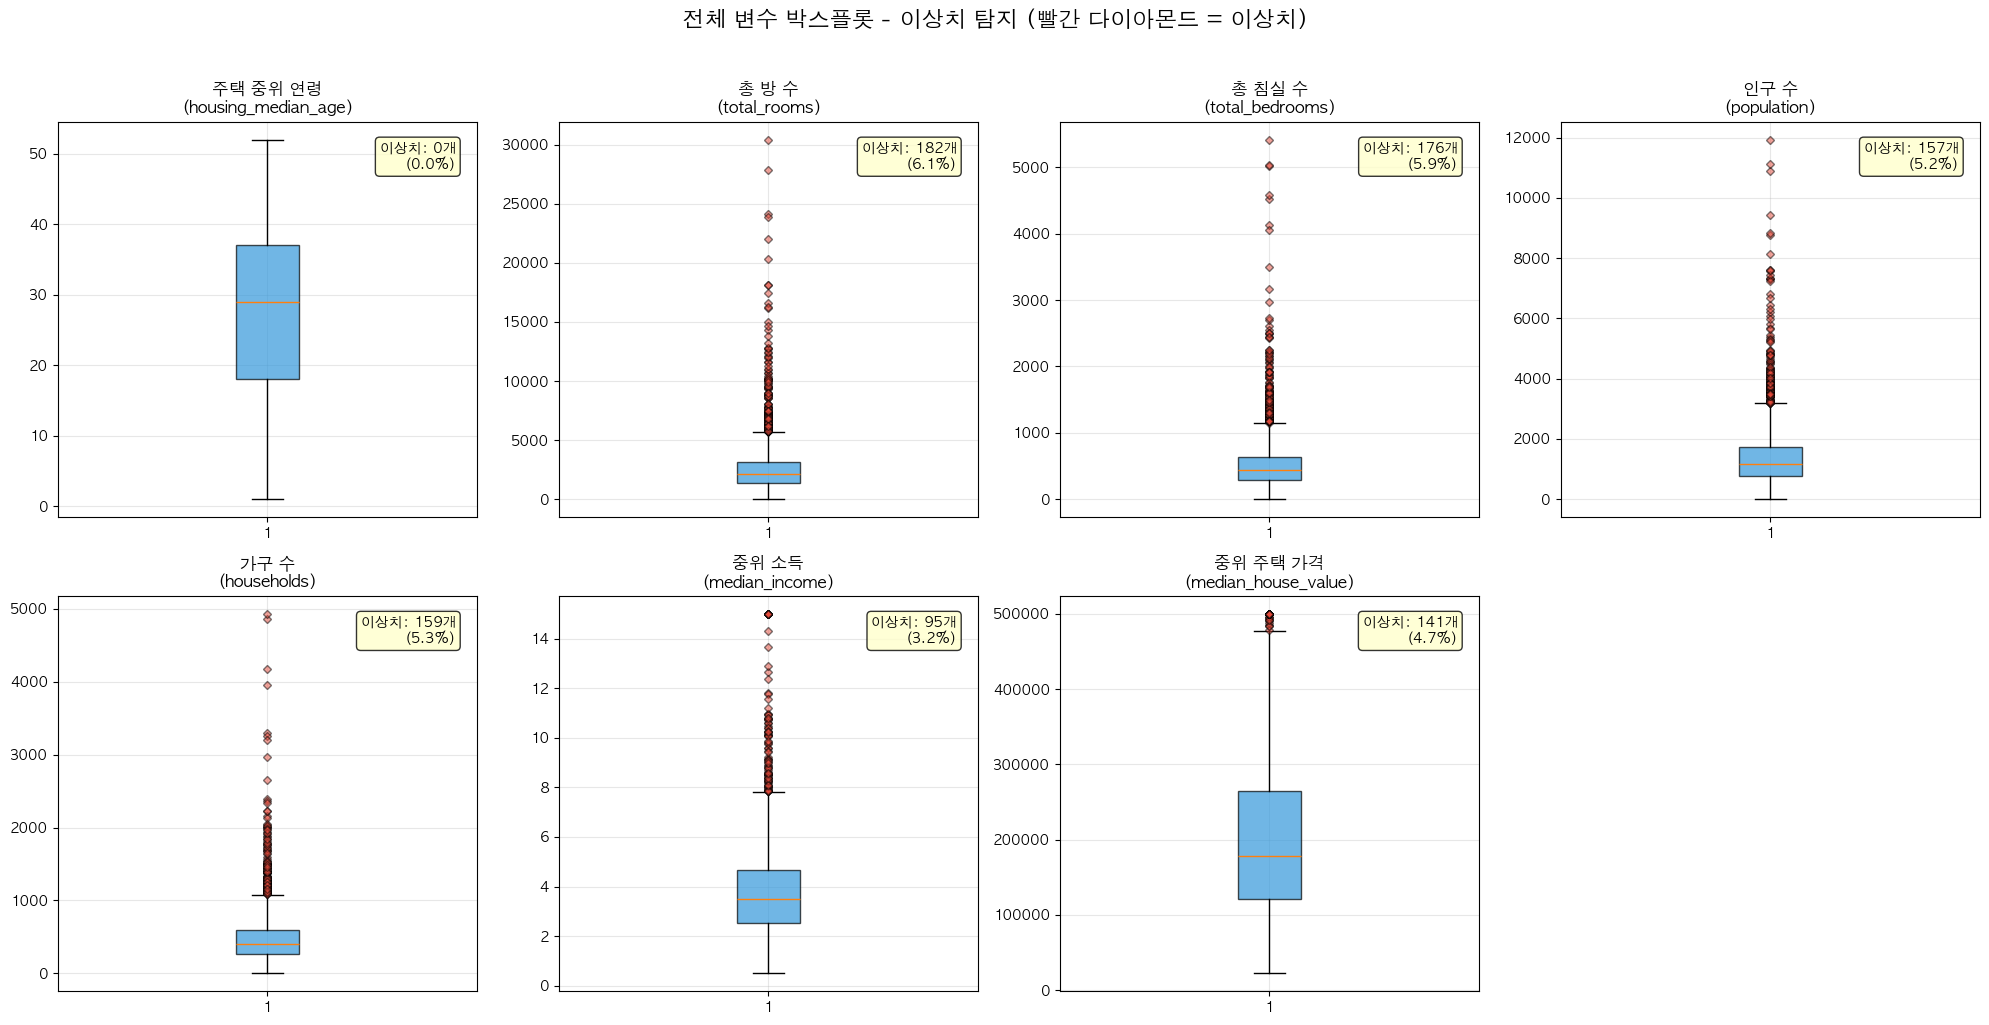

In [21]:
# === 전체 수치형 변수 박스플롯 (이상치 한눈에 파악) ===
# 스케일이 다른 변수들을 한 화면에서 비교하기 위해 개별 subplot으로 그림

# 이상치 판별이 의미 있는 컬럼 선택 (longitude, latitude는 좌표이므로 제외)
outlier_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms',
                'population', 'households', 'median_income', 'median_house_value']

# 한글 컬럼 설명 (그래프 제목용)
col_names_kr = {
    'housing_median_age': '주택 중위 연령',
    'total_rooms': '총 방 수',
    'total_bedrooms': '총 침실 수',
    'population': '인구 수',
    'households': '가구 수',
    'median_income': '중위 소득',
    'median_house_value': '중위 주택 가격'
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()  # 2D 배열을 1D로 변환하여 인덱싱 편하게

for i, col in enumerate(outlier_cols):
    # 박스플롯 그리기 (빨간 다이아몬드가 이상치)
    bp = axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                         boxprops=dict(facecolor='#3498db', alpha=0.7),
                         flierprops=dict(marker='D', markerfacecolor='#e74c3c',
                                        markersize=4, alpha=0.5))
    axes[i].set_title(f'{col_names_kr[col]}\n({col})', fontsize=12)

    # IQR 방식으로 이상치 개수 계산
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    pct = n_outliers / len(df) * 100

    # 이상치 개수를 그래프 안에 표시
    axes[i].text(0.95, 0.95, f'이상치: {n_outliers}개\n({pct:.1f}%)',
                transform=axes[i].transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='#ffffcc', alpha=0.8))
    axes[i].grid(True, alpha=0.3)

# 마지막 빈 subplot 숨기기
axes[7].set_visible(False)

plt.suptitle('전체 변수 박스플롯 - 이상치 탐지 (빨간 다이아몬드 = 이상치)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# === 각 변수별 IQR 이상치 요약 테이블 ===
# 어떤 변수에 이상치가 많은지 한눈에 비교

outlier_summary = []
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR  # 하한 경계
    upper = Q3 + 1.5 * IQR  # 상한 경계
    # 하한 미만 이상치 개수
    n_lower = (df[col] < lower).sum()
    # 상한 초과 이상치 개수
    n_upper = (df[col] > upper).sum()
    n_total = n_lower + n_upper

    outlier_summary.append({
        '변수': col,
        '한글명': col_names_kr[col],
        'Q1': f'{Q1:,.1f}',
        'Q3': f'{Q3:,.1f}',
        'IQR': f'{IQR:,.1f}',
        '하한 이상치': n_lower,
        '상한 이상치': n_upper,
        '총 이상치': n_total,
        '이상치 비율(%)': f'{n_total / len(df) * 100:.1f}'
    })

outlier_df = pd.DataFrame(outlier_summary)
# 이상치가 많은 순서로 정렬
outlier_df = outlier_df.sort_values('총 이상치', ascending=False).reset_index(drop=True)

print('=== 변수별 IQR 이상치 요약 (이상치 많은 순) ===')
print(outlier_df.to_string(index=False))
print()
print('※ 하한 이상치: Q1 - 1.5×IQR 미만 (비정상적으로 작은 값)')
print('※ 상한 이상치: Q3 + 1.5×IQR 초과 (비정상적으로 큰 값)')

=== 변수별 IQR 이상치 요약 (이상치 많은 순) ===
                변수      한글명        Q1        Q3       IQR  하한 이상치  상한 이상치  총 이상치 이상치 비율(%)
       total_rooms    총 방 수   1,401.0   3,129.0   1,728.0       0     182    182       6.1
    total_bedrooms   총 침실 수     291.0     636.0     345.0       0     176    176       5.9
        households     가구 수     273.0     597.2     324.2       0     159    159       5.3
        population     인구 수     780.0   1,742.8     962.8       0     157    157       5.2
median_house_value 중위 주택 가격 121,200.0 263,975.0 142,775.0       0     141    141       4.7
     median_income    중위 소득       2.5       4.7       2.1       0      95     95       3.2
housing_median_age 주택 중위 연령      18.0      37.0      19.0       0       0      0       0.0

※ 하한 이상치: Q1 - 1.5×IQR 미만 (비정상적으로 작은 값)
※ 상한 이상치: Q3 + 1.5×IQR 초과 (비정상적으로 큰 값)


### 산점도로 변수 간 관계에서 이상치 패턴 파악
> 박스플롯은 **단일 변수**의 이상치만 보여줍니다.  
> 산점도는 **두 변수 간 관계**에서 벗어난 이상치를 발견할 수 있어 더 정밀한 분석이 가능합니다.  
> 이상치(빨간 점)는 IQR 기준으로 **어느 한 축이라도** 이상치인 데이터입니다.

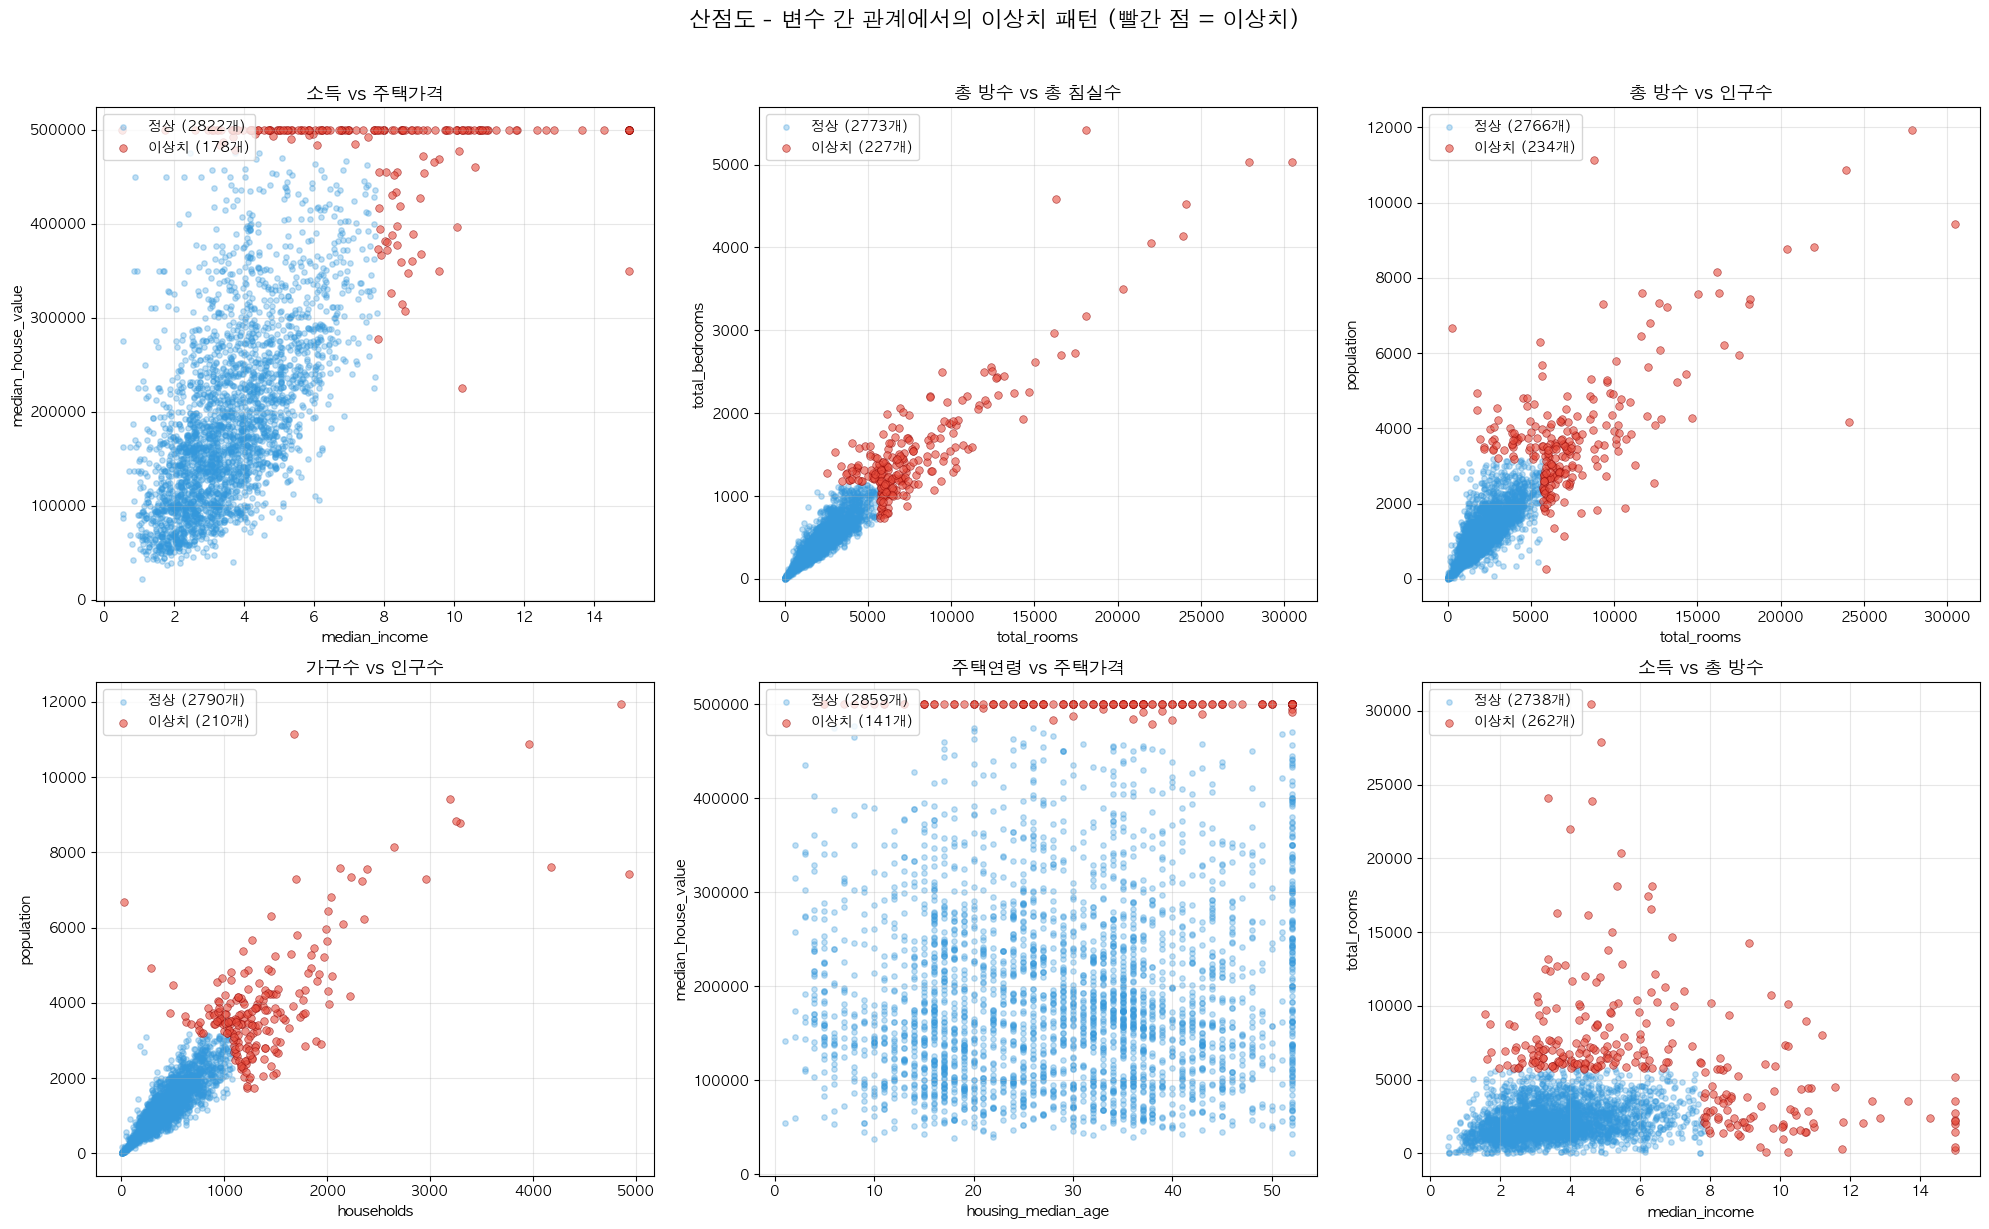

In [23]:
# === 산점도: 주요 변수 조합별 이상치 시각화 ===
# median_house_value와 관련 깊은 변수 조합 + 상호 관련 변수 조합

# IQR 기준 이상치 여부를 판별하는 함수
def is_outlier_iqr(series):
    """IQR 방식으로 이상치 여부를 True/False로 반환"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)

# 의미 있는 산점도 조합 선정 (변수 간 관계가 있는 쌍)
scatter_pairs = [
    ('median_income', 'median_house_value', '소득 vs 주택가격'),
    ('total_rooms', 'total_bedrooms', '총 방수 vs 총 침실수'),
    ('total_rooms', 'population', '총 방수 vs 인구수'),
    ('households', 'population', '가구수 vs 인구수'),
    ('housing_median_age', 'median_house_value', '주택연령 vs 주택가격'),
    ('median_income', 'total_rooms', '소득 vs 총 방수'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (x_col, y_col, title) in enumerate(scatter_pairs):
    # 두 변수 중 하나라도 IQR 이상치이면 이상치로 판별
    outlier_mask = is_outlier_iqr(df[x_col]) | is_outlier_iqr(df[y_col])
    normal = df[~outlier_mask]   # 정상 데이터
    outliers = df[outlier_mask]  # 이상치 데이터

    # 정상 데이터: 파란 점 (작게, 반투명)
    axes[i].scatter(normal[x_col], normal[y_col],
                   c='#3498db', alpha=0.3, s=15, label=f'정상 ({len(normal)}개)')
    # 이상치 데이터: 빨간 점 (크게, 눈에 띄게)
    axes[i].scatter(outliers[x_col], outliers[y_col],
                   c='#e74c3c', alpha=0.6, s=30, label=f'이상치 ({len(outliers)}개)',
                   edgecolors='darkred', linewidth=0.5)

    axes[i].set_xlabel(x_col, fontsize=11)
    axes[i].set_ylabel(y_col, fontsize=11)
    axes[i].set_title(title, fontsize=13)
    axes[i].legend(fontsize=10, loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('산점도 - 변수 간 관계에서의 이상치 패턴 (빨간 점 = 이상치)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

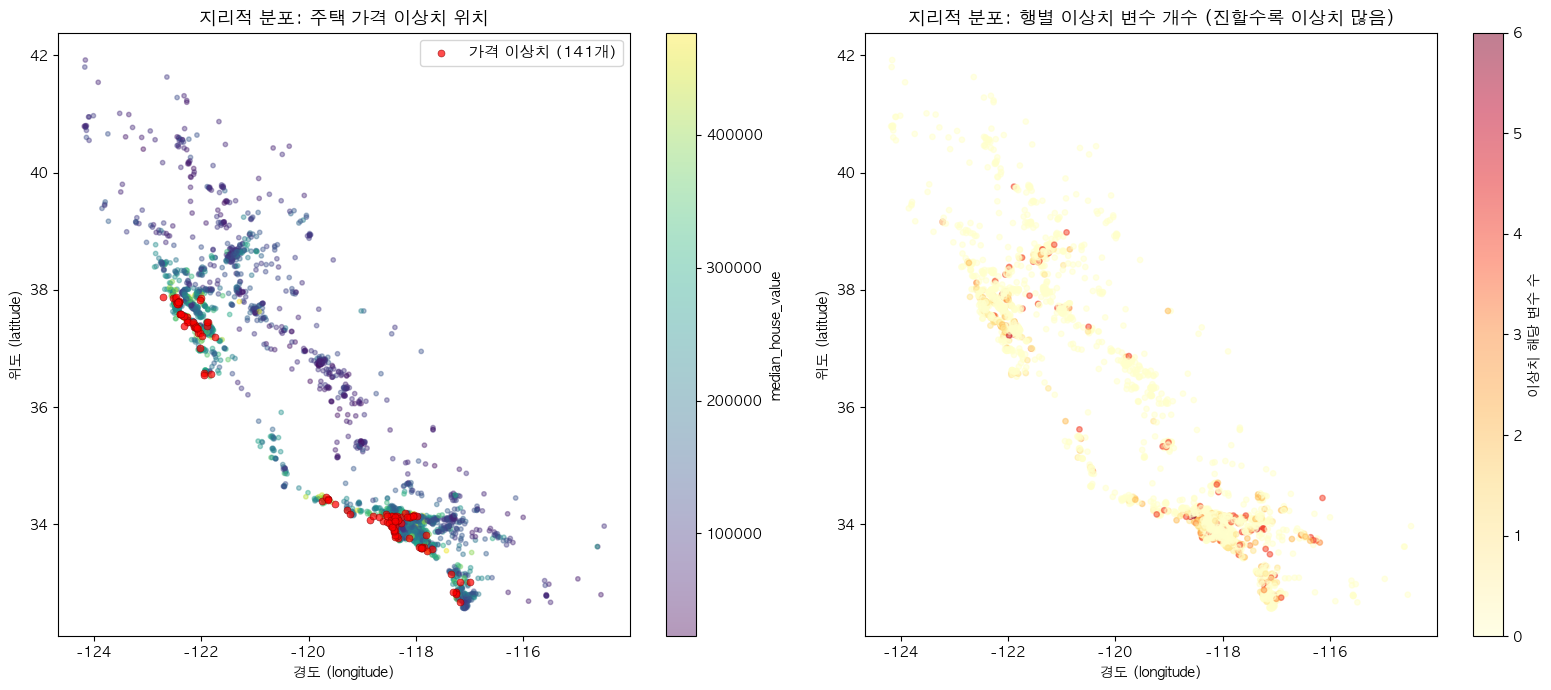


2개 이상 변수에서 동시에 이상치인 행: 243개 (8.1%)
→ 이러한 다중 이상치는 데이터 품질 문제일 가능성이 높아 우선 검토 대상입니다.


In [24]:
# === 지리적 산점도: 위치 기반 이상치 분포 ===
# 캘리포니아 지도 위에 이상치가 어디에 분포하는지 확인

outlier_mask_price = is_outlier_iqr(df['median_house_value'])
normal_geo = df[~outlier_mask_price]
outliers_geo = df[outlier_mask_price]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 그래프 1: 전체 데이터의 주택 가격 분포 (색상 = 가격)
scatter1 = axes[0].scatter(normal_geo['longitude'], normal_geo['latitude'],
                           c=normal_geo['median_house_value'], cmap='viridis',
                           alpha=0.4, s=10)
axes[0].scatter(outliers_geo['longitude'], outliers_geo['latitude'],
               c='red', alpha=0.7, s=25, edgecolors='darkred', linewidth=0.5,
               label=f'가격 이상치 ({len(outliers_geo)}개)')
axes[0].set_xlabel('경도 (longitude)')
axes[0].set_ylabel('위도 (latitude)')
axes[0].set_title('지리적 분포: 주택 가격 이상치 위치', fontsize=13)
axes[0].legend(fontsize=11)
plt.colorbar(scatter1, ax=axes[0], label='median_house_value')

# 그래프 2: 다중 변수 이상치 (하나라도 이상치인 데이터)
# 모든 주요 변수에서 이상치 여부를 종합적으로 판단
multi_outlier_mask = pd.DataFrame({
    col: is_outlier_iqr(df[col]) for col in outlier_cols
})
# 각 행에서 이상치인 변수의 개수를 카운트
outlier_count_per_row = multi_outlier_mask.sum(axis=1)

scatter2 = axes[1].scatter(df['longitude'], df['latitude'],
                           c=outlier_count_per_row, cmap='YlOrRd',
                           alpha=0.5, s=15)
axes[1].set_xlabel('경도 (longitude)')
axes[1].set_ylabel('위도 (latitude)')
axes[1].set_title('지리적 분포: 행별 이상치 변수 개수 (진할수록 이상치 많음)', fontsize=13)
plt.colorbar(scatter2, ax=axes[1], label='이상치 해당 변수 수')

plt.tight_layout()
plt.show()

# 이상치가 2개 이상 변수에서 동시에 나타나는 행 (다중 이상치)
multi_outlier_rows = df[outlier_count_per_row >= 2]
print(f'\n2개 이상 변수에서 동시에 이상치인 행: {len(multi_outlier_rows)}개 ({len(multi_outlier_rows)/len(df)*100:.1f}%)')
print('→ 이러한 다중 이상치는 데이터 품질 문제일 가능성이 높아 우선 검토 대상입니다.')

# 🔍 결측치(Missing Value) 처리 완전 가이드
## median_house_value 컬럼에 랜덤 결측치를 생성하고, 초급~고급 수준의 처리 방법을 학습합니다.

---

### 학습 목차
1. **[준비] 랜덤 결측치 생성**
2. **[초급] 결측치 확인 방법**
3. **[초급] 결측치 삭제 (dropna)**
4. **[초급] 평균/중앙값/최빈값으로 대체 (fillna)**
5. **[중급] 앞/뒤 값으로 채우기 (ffill, bfill)**
6. **[중급] 그룹별 평균으로 대체**
7. **[중급] 보간법 (interpolate)**
8. **[고급] KNN Imputer (K-최근접 이웃 대체)**
9. **[고급] 회귀 모델 기반 대체**
10. **[비교] 각 방법별 결과 비교 시각화**

## 1. [준비] 랜덤 결측치 생성
> 원본 데이터를 보존하면서, `median_house_value` 컬럼에 **10% 비율**로 랜덤 결측치(NaN)를 주입합니다.

In [25]:
# === 랜덤 결측치 생성 ===
# 원본 데이터를 보존하기 위해 복사본(df_missing)을 만들어서 작업
df_missing = df.copy()

# 재현 가능한 결과를 위해 랜덤 시드 고정
np.random.seed(42)

# 전체 데이터의 10% (300개)를 랜덤으로 선택하여 결측치로 변환
missing_ratio = 0.10  # 결측치 비율: 10%
n_missing = int(len(df_missing) * missing_ratio)  # 결측치 개수 계산

# 중복 없이 랜덤 인덱스를 선택 (replace=False: 같은 인덱스 중복 선택 방지)
missing_indices = np.random.choice(df_missing.index, size=n_missing, replace=False)

# 원본 값을 별도로 저장 (나중에 복원 정확도 비교용)
original_values = df_missing.loc[missing_indices, 'median_house_value'].copy()

# 선택된 인덱스의 median_house_value를 NaN으로 변환
df_missing.loc[missing_indices, 'median_house_value'] = np.nan

print(f"=== 결측치 생성 완료 ===")
print(f"전체 데이터 수: {len(df_missing)}개")
print(f"생성된 결측치 수: {n_missing}개 ({missing_ratio*100:.0f}%)")
print(f"결측치가 아닌 데이터 수: {df_missing['median_house_value'].notna().sum()}개")
print()

# 결측치가 포함된 데이터 확인 (상위 10개)
print("=== 결측치가 포함된 행 (상위 10개) ===")
df_missing[df_missing['median_house_value'].isna()].head(10)

=== 결측치 생성 완료 ===
전체 데이터 수: 3000개
생성된 결측치 수: 300개 (10%)
결측치가 아닌 데이터 수: 2700개

=== 결측치가 포함된 행 (상위 10개) ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,NaN
14,-117.97,33.73,27.0,2097.0,325.0,1217.0,331.0,5.7121,NaN
30,-119.35,36.33,14.0,1195.0,220.0,568.0,229.0,3.1486,NaN
32,-121.13,39.31,17.0,3442.0,705.0,1693.0,619.0,2.8102,NaN
44,-118.23,34.13,48.0,1308.0,286.0,835.0,294.0,4.2891,NaN
45,-117.24,33.17,4.0,9998.0,1874.0,3925.0,1672.0,4.2826,NaN
51,-119.42,35.97,21.0,554.0,121.0,426.0,122.0,2.3516,NaN
52,-122.21,37.80,39.0,2003.0,500.0,1109.0,464.0,3.0682,NaN
63,-121.67,40.87,31.0,1581.0,299.0,776.0,287.0,2.9063,NaN
67,-117.53,33.92,12.0,2290.0,319.0,728.0,228.0,6.1561,NaN


## 2. [초급] 결측치 확인 방법
> 데이터 분석의 첫 단계는 결측치가 **어디에, 얼마나** 있는지 파악하는 것입니다.

=== 방법 1: 컬럼별 결측치 개수 (isnull().sum()) ===
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms          0
population              0
households              0
median_income           0
median_house_value    300
dtype: int64

=== 방법 2: 데이터프레임 정보 (info()) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  2700 non-null   float64
dtypes: float64(9)
memory usage:

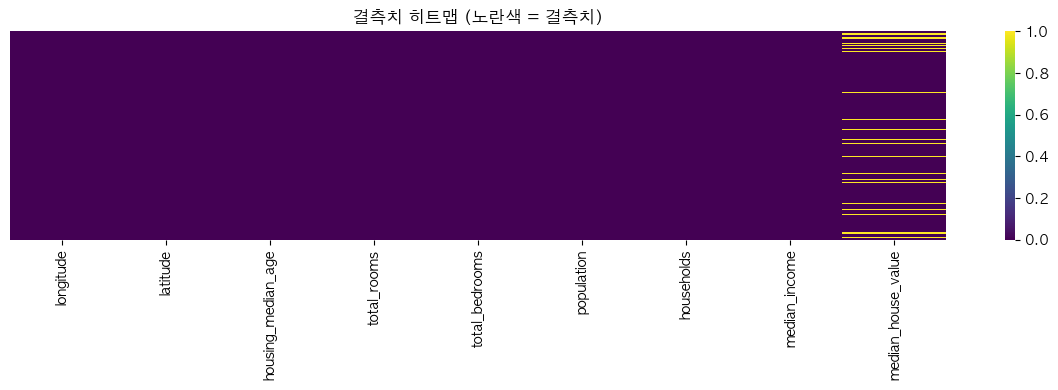

In [26]:
# === 결측치 확인 방법 모음 ===

# 방법 1: isnull().sum() - 각 컬럼별 결측치 개수 확인 (가장 기본)
print("=== 방법 1: 컬럼별 결측치 개수 (isnull().sum()) ===")
print(df_missing.isnull().sum())
print()

# 방법 2: info() - 데이터프레임 전체 정보 (Non-Null Count로 결측치 유추 가능)
print("=== 방법 2: 데이터프레임 정보 (info()) ===")
df_missing.info()
print()

# 방법 3: 결측치 비율을 퍼센트로 확인 (실무에서 매우 유용)
print("=== 방법 3: 컬럼별 결측치 비율 (%) ===")
missing_pct = (df_missing.isnull().sum() / len(df_missing) * 100).round(2)
print(missing_pct[missing_pct > 0])  # 결측치가 있는 컬럼만 출력
print()

# 방법 4: 결측치 시각화 (히트맵) - 결측치 패턴을 한눈에 파악
plt.figure(figsize=(12, 4))
# isnull() 결과를 히트맵으로 표시: 노란색=결측치, 보라색=정상값
sns.heatmap(df_missing.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('결측치 히트맵 (노란색 = 결측치)')
plt.tight_layout()
plt.show()

## 3. [초급] 결측치 삭제 (dropna)
> 가장 단순한 방법으로, 결측치가 포함된 **행 자체를 삭제**합니다.  
> **장점**: 간단하고 빠름  
> **단점**: 데이터 손실 발생, 결측치가 많으면 분석 결과 왜곡 가능

In [27]:
# === 방법 1: 결측치 삭제 (dropna) ===
# subset 파라미터: 특정 컬럼에 결측치가 있는 행만 삭제 (다른 컬럼은 무관)
df_dropna = df_missing.dropna(subset=['median_house_value'])

print(f"삭제 전 데이터 수: {len(df_missing)}개")
print(f"삭제 후 데이터 수: {len(df_dropna)}개")
print(f"삭제된 행 수: {len(df_missing) - len(df_dropna)}개")
print()

# 삭제 후 기초 통계량 비교
print("=== 원본 vs 삭제 후 기초 통계량 비교 ===")
comparison = pd.DataFrame({
    '원본': df['median_house_value'].describe(),
    '삭제 후': df_dropna['median_house_value'].describe()
})
comparison['차이'] = comparison['삭제 후'] - comparison['원본']
print(comparison.round(2))
print()
print("※ 결측치가 랜덤이면 통계량 차이가 작지만, 특정 패턴이 있으면 크게 왜곡될 수 있음")

삭제 전 데이터 수: 3000개
삭제 후 데이터 수: 2700개
삭제된 행 수: 300개

=== 원본 vs 삭제 후 기초 통계량 비교 ===
              원본       삭제 후        차이
count    3000.00    2700.00   -300.00
mean   205846.28  205559.86   -286.42
std    113119.69  112849.86   -269.82
min     22500.00   37500.00  15000.00
25%    121200.00  120700.00   -500.00
50%    177650.00  178100.00    450.00
75%    263975.00  264550.00    575.00
max    500001.00  500001.00      0.00

※ 결측치가 랜덤이면 통계량 차이가 작지만, 특정 패턴이 있으면 크게 왜곡될 수 있음


## 4. [초급] 평균 / 중앙값 / 최빈값으로 대체 (fillna)
> 결측치를 **하나의 대표값**으로 일괄 대체하는 방법입니다.
> - **평균(mean)**: 정규분포에 가까운 데이터에 적합
> - **중앙값(median)**: 이상치가 많거나 치우친 분포에 적합 (더 robust)
> - **최빈값(mode)**: 범주형 데이터에 주로 사용

In [28]:
# === 방법 2: 평균(mean)으로 대체 ===
df_mean = df_missing.copy()
# 결측치가 아닌 값들의 평균을 계산하여 결측치를 채움
mean_value = df_mean['median_house_value'].mean()
df_mean['median_house_value'] = df_mean['median_house_value'].fillna(mean_value)

print(f"평균값으로 대체: {mean_value:,.0f}")
print()

# === 방법 3: 중앙값(median)으로 대체 ===
df_median = df_missing.copy()
# 중앙값: 데이터를 크기순으로 나열했을 때 정중앙에 위치한 값
median_value = df_median['median_house_value'].median()
df_median['median_house_value'] = df_median['median_house_value'].fillna(median_value)

print(f"중앙값으로 대체: {median_value:,.0f}")
print()

# === 방법 4: 최빈값(mode)으로 대체 ===
df_mode = df_missing.copy()
# mode()는 여러 개의 최빈값을 반환할 수 있으므로 [0]으로 첫 번째 값 선택
mode_value = df_mode['median_house_value'].mode()[0]
df_mode['median_house_value'] = df_mode['median_house_value'].fillna(mode_value)

print(f"최빈값으로 대체: {mode_value:,.0f}")
print()

# 세 가지 방법 비교
print("=== 대체 방법별 기초 통계량 비교 ===")
comparison = pd.DataFrame({
    '원본': df['median_house_value'].describe(),
    '평균 대체': df_mean['median_house_value'].describe(),
    '중앙값 대체': df_median['median_house_value'].describe(),
    '최빈값 대체': df_mode['median_house_value'].describe()
}).round(2)
print(comparison)

평균값으로 대체: 205,560

중앙값으로 대체: 178,100

최빈값으로 대체: 500,001

=== 대체 방법별 기초 통계량 비교 ===
              원본      평균 대체     중앙값 대체     최빈값 대체
count    3000.00    3000.00    3000.00    3000.00
mean   205846.28  205559.86  202813.87  235003.97
std    113119.69  107056.80  107373.39  138803.32
min     22500.00   37500.00   37500.00   37500.00
25%    121200.00  129175.00  129175.00  129175.00
50%    177650.00  192200.00  178100.00  192200.00
75%    263975.00  250000.00  250000.00  309925.00
max    500001.00  500001.00  500001.00  500001.00


## 5. [중급] 앞/뒤 값으로 채우기 (Forward Fill / Backward Fill)
> 시계열 데이터에서 자주 사용하는 방법으로, **바로 앞(ffill)** 또는 **바로 뒤(bfill)**의 값으로 결측치를 채웁니다.  
> **적합한 경우**: 시간 순서가 있는 데이터 (주가, 센서 데이터 등)  
> **주의**: 순서에 의미가 없는 데이터에는 부적합

In [29]:
# === 방법 5: 앞/뒤 값으로 채우기 (ffill / bfill) ===

# ffill (Forward Fill): 바로 앞의 유효한 값으로 채움
# 예: [100, NaN, NaN, 200] → [100, 100, 100, 200]
df_ffill = df_missing.copy()
df_ffill['median_house_value'] = df_ffill['median_house_value'].ffill()

# bfill (Backward Fill): 바로 뒤의 유효한 값으로 채움
# 예: [100, NaN, NaN, 200] → [100, 200, 200, 200]
df_bfill = df_missing.copy()
df_bfill['median_house_value'] = df_bfill['median_house_value'].bfill()

print("=== ffill vs bfill 결과 비교 (결측치였던 위치의 값) ===")
comparison_fb = pd.DataFrame({
    '원본값': original_values,
    'ffill 대체값': df_ffill.loc[missing_indices, 'median_house_value'],
    'bfill 대체값': df_bfill.loc[missing_indices, 'median_house_value']
})
print(comparison_fb.head(15))
print()

# 남아있는 결측치 확인 (첫 번째 행이 결측치면 ffill로 채울 수 없음)
print(f"ffill 후 남은 결측치: {df_ffill['median_house_value'].isna().sum()}개")
print(f"bfill 후 남은 결측치: {df_bfill['median_house_value'].isna().sum()}개")

=== ffill vs bfill 결과 비교 (결측치였던 위치의 값) ===
           원본값  ffill 대체값  bfill 대체값
1801  119400.0    95800.0   213200.0
1190  133600.0   243800.0   228600.0
1817  173600.0   156300.0   206300.0
251   218600.0   232700.0   135000.0
2505  276700.0    93100.0   174400.0
1117  146800.0   120400.0    74700.0
1411  166300.0   161600.0   155700.0
2113  197200.0   119600.0   104200.0
408   162500.0    63400.0   288200.0
2579  287800.0   253800.0   388300.0
2254  192900.0   290400.0   318500.0
52    156500.0   160900.0   187500.0
644    81300.0   249200.0   357400.0
1763  410700.0   122700.0   394700.0
2776  115000.0   109800.0   364200.0

ffill 후 남은 결측치: 1개
bfill 후 남은 결측치: 0개


## 6. [중급] 그룹별 평균으로 대체
> 단순 전체 평균 대신, **특정 그룹의 평균**으로 대체하면 더 정확한 값을 채울 수 있습니다.  
> 여기서는 `housing_median_age`를 구간별로 나누어 각 구간의 평균으로 대체합니다.  
> **핵심 아이디어**: "비슷한 특성을 가진 데이터끼리의 평균이 더 정확하다"

In [30]:
# === 방법 6: 그룹별 평균으로 대체 ===
df_group = df_missing.copy()

# housing_median_age를 10년 단위 구간으로 나누기
# pd.cut(): 연속형 변수를 범주형 구간으로 변환
# 예: 0~10, 10~20, 20~30, 30~40, 40~50, 50~60
df_group['age_group'] = pd.cut(df_group['housing_median_age'],
                                bins=[0, 10, 20, 30, 40, 50, 60],
                                labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60'])

# 각 연령 구간별 median_house_value의 평균 확인
print("=== 연령 구간별 평균 집값 ===")
group_means = df_group.groupby('age_group', observed=False)['median_house_value'].mean()
print(group_means.apply(lambda x: f"{x:,.0f}"))
print()

# transform(): 그룹별 연산 결과를 원래 데이터프레임 크기에 맞게 변환
# 각 행에 해당 그룹의 평균값이 매핑됨
group_mean_values = df_group.groupby('age_group', observed=False)['median_house_value'].transform('mean')

# 결측치를 해당 그룹의 평균으로 대체
df_group['median_house_value'] = df_group['median_house_value'].fillna(group_mean_values)

# 보조 컬럼 삭제 (분석에 불필요)
df_group = df_group.drop(columns=['age_group'])

print(f"그룹별 평균 대체 후 결측치: {df_group['median_house_value'].isna().sum()}개")
print()

# 원본과 비교
print("=== 그룹별 평균 대체 vs 전체 평균 대체 비교 ===")
comparison_group = pd.DataFrame({
    '원본': df['median_house_value'].describe(),
    '전체 평균 대체': df_mean['median_house_value'].describe(),
    '그룹별 평균 대체': df_group['median_house_value'].describe()
}).round(2)
print(comparison_group)

=== 연령 구간별 평균 집값 ===
age_group
0-10     196,959
10-20    189,109
20-30    209,079
30-40    207,448
40-50    201,805
50-60    258,942
Name: median_house_value, dtype: object

그룹별 평균 대체 후 결측치: 0개

=== 그룹별 평균 대체 vs 전체 평균 대체 비교 ===
              원본   전체 평균 대체  그룹별 평균 대체
count    3000.00    3000.00    3000.00
mean   205846.28  205559.86  205340.59
std    113119.69  107056.80  107154.38
min     22500.00   37500.00   37500.00
25%    121200.00  129175.00  129175.00
50%    177650.00  192200.00  189108.58
75%    263975.00  250000.00  252450.00
max    500001.00  500001.00  500001.00


## 7. [중급] 보간법 (Interpolation)
> 결측치의 **앞뒤 값을 이용해 수학적으로 추정**하는 방법입니다.  
> - **선형 보간(linear)**: 두 점 사이를 직선으로 연결하여 추정 (기본값)
> - **다항식 보간(polynomial)**: 곡선으로 연결하여 더 정밀하게 추정
> - 시계열 데이터나 연속적인 데이터에 특히 효과적

In [31]:
# === 방법 7: 보간법 (Interpolation) ===

# 선형 보간: 앞뒤 값 사이를 직선으로 연결하여 중간값 추정
# 예: [100, NaN, NaN, 400] → [100, 200, 300, 400] (균등 간격으로 채움)
df_linear = df_missing.copy()
df_linear['median_house_value'] = df_linear['median_house_value'].interpolate(method='linear')

# 다항식 보간 (2차): 앞뒤 값을 이용해 2차 곡선으로 추정 (더 부드러운 변화)
df_poly = df_missing.copy()
df_poly['median_house_value'] = df_poly['median_house_value'].interpolate(method='polynomial', order=2)

print("=== 보간법 결과 비교 (결측치였던 위치) ===")
interp_comparison = pd.DataFrame({
    '원본값': original_values,
    '선형 보간': df_linear.loc[missing_indices, 'median_house_value'],
    '다항식 보간(2차)': df_poly.loc[missing_indices, 'median_house_value']
})
# 원본값과의 오차도 함께 표시
interp_comparison['선형_오차'] = abs(interp_comparison['선형 보간'] - interp_comparison['원본값'])
interp_comparison['다항식_오차'] = abs(interp_comparison['다항식 보간(2차)'] - interp_comparison['원본값'])
print(interp_comparison.head(15).round(0))
print()

# 평균 오차 비교
print("=== 평균 절대 오차 (MAE) 비교 ===")
mae_linear = abs(df_linear.loc[missing_indices, 'median_house_value'] - original_values).mean()
mae_poly = abs(df_poly.loc[missing_indices, 'median_house_value'] - original_values).mean()
print(f"선형 보간 MAE: {mae_linear:,.0f}")
print(f"다항식 보간 MAE: {mae_poly:,.0f}")

=== 보간법 결과 비교 (결측치였던 위치) ===
           원본값     선형 보간  다항식 보간(2차)     선형_오차    다항식_오차
1801  119400.0  154500.0    166032.0   35100.0   46632.0
1190  133600.0  236200.0    211636.0  102600.0   78036.0
1817  173600.0  181300.0    201446.0    7700.0   27846.0
251   218600.0  183850.0    222605.0   34750.0    4005.0
2505  276700.0  133750.0     51619.0  142950.0  225081.0
1117  146800.0   97550.0     61485.0   49250.0   85315.0
1411  166300.0  159633.0    152653.0    6667.0   13647.0
2113  197200.0  111900.0     90363.0   85300.0  106837.0
408   162500.0  175800.0    146129.0   13300.0   16371.0
2579  287800.0  321050.0    400591.0   33250.0  112791.0
2254  192900.0  304450.0    325838.0  111550.0  132938.0
52    156500.0  178633.0    175024.0   22133.0   18524.0
644    81300.0  303300.0    332290.0  222000.0  250990.0
1763  410700.0  304033.0    486671.0  106667.0   75971.0
2776  115000.0  237000.0    253874.0  122000.0  138874.0

=== 평균 절대 오차 (MAE) 비교 ===
선형 보간 MAE: 113,905
다항식 보간 MAE: 1

### 선형 보간 vs 다항식 보간 - 그림으로 이해하기
> 아래 그래프에서 **빨간 X**가 결측치(NaN) 위치이고, 각 보간법이 이 빈 자리를 어떻게 채우는지 시각적으로 비교합니다.
>
> **MAE = Mean Absolute Error (평균 절대 오차)**  
> 예측값과 실제값의 차이(절대값)를 평균낸 것으로, 값이 작을수록 정확합니다.

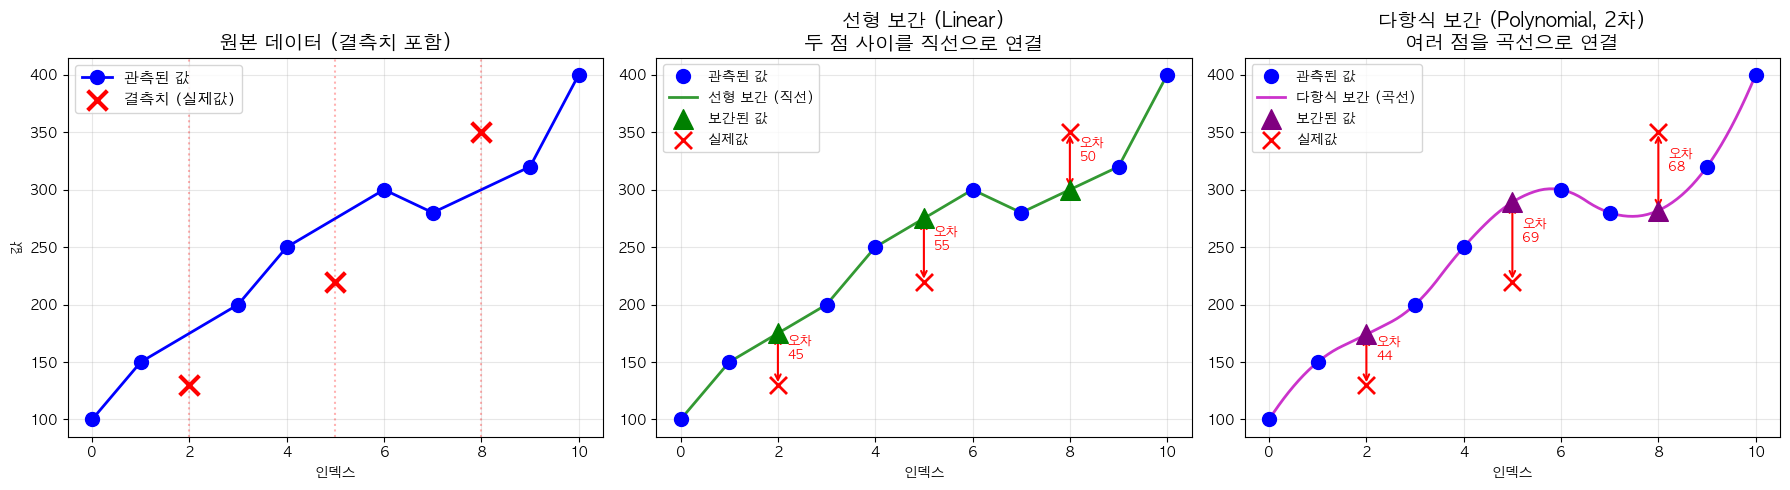


  선형 보간 (Linear Interpolation)
  → 결측치 양쪽 두 점을 '직선'으로 연결하여 추정
  → 계산이 빠르고 단순, 급격한 변화가 없는 데이터에 적합

  다항식 보간 (Polynomial Interpolation)
  → 주변 여러 점을 이용해 '곡선(2차 함수)'으로 추정
  → 데이터가 곡선 패턴을 가질 때 더 정확
  → order가 높을수록 복잡한 곡선 (과적합 주의)

  MAE = Mean Absolute Error (평균 절대 오차)
  공식: MAE = (1/n) × Σ|실제값 - 예측값|
  → 각 데이터 포인트의 오차 절대값을 모두 더해서 평균
  → 값이 작을수록 예측이 정확함을 의미


In [32]:
# === 보간법 시각적 설명: 간단한 예시 데이터로 원리 이해 ===
from scipy.interpolate import interp1d

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 예시 데이터 생성 (보간 원리를 쉽게 보여주기 위한 소규모 데이터) ---
# x좌표 (인덱스), y좌표 (실제 값)
x_all = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_true = np.array([100, 150, 130, 200, 250, 220, 300, 280, 350, 320, 400])

# 결측치 위치 (인덱스 2, 5, 8을 NaN으로 설정)
missing_idx = [2, 5, 8]
y_with_nan = y_true.astype(float).copy()
y_with_nan[missing_idx] = np.nan

# 관측된 값만 추출 (결측치가 아닌 값)
observed_mask = ~np.isnan(y_with_nan)
x_obs = x_all[observed_mask]
y_obs = y_with_nan[observed_mask]

# ===== 그래프 1: 결측치가 있는 원본 데이터 =====
axes[0].plot(x_obs, y_obs, 'bo-', markersize=10, label='관측된 값', linewidth=2)
# 결측치 위치를 빨간 X로 표시
axes[0].scatter(x_all[missing_idx], y_true[missing_idx], color='red',
               marker='x', s=200, linewidth=3, zorder=5, label='결측치 (실제값)')
# 결측치 위치에 세로 점선 표시
for idx in missing_idx:
    axes[0].axvline(x=idx, color='red', linestyle=':', alpha=0.3)
axes[0].set_title('원본 데이터 (결측치 포함)', fontsize=14)
axes[0].set_xlabel('인덱스')
axes[0].set_ylabel('값')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ===== 그래프 2: 선형 보간 (Linear Interpolation) =====
# 원리: 결측치 양쪽의 관측값 두 점을 직선으로 연결하여 중간값 추정
y_linear = pd.Series(y_with_nan).interpolate(method='linear').values

axes[1].plot(x_obs, y_obs, 'bo', markersize=10, label='관측된 값', zorder=5)
# 선형 보간 결과: 직선으로 연결
axes[1].plot(x_all, y_linear, 'g-', linewidth=2, label='선형 보간 (직선)', alpha=0.8)
# 보간된 값을 초록 삼각형으로 강조
axes[1].scatter(x_all[missing_idx], y_linear[missing_idx], color='green',
               marker='^', s=200, zorder=5, label='보간된 값')
# 실제값과의 차이를 화살표로 표시
for idx in missing_idx:
    axes[1].annotate('', xy=(idx, y_true[idx]), xytext=(idx, y_linear[idx]),
                    arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
    mid_y = (y_true[idx] + y_linear[idx]) / 2
    axes[1].text(idx + 0.2, mid_y, f'오차\n{abs(y_true[idx]-y_linear[idx]):.0f}',
                fontsize=9, color='red')
axes[1].scatter(x_all[missing_idx], y_true[missing_idx], color='red',
               marker='x', s=150, linewidth=2, zorder=5, label='실제값')
axes[1].set_title('선형 보간 (Linear)\n두 점 사이를 직선으로 연결', fontsize=14)
axes[1].set_xlabel('인덱스')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# ===== 그래프 3: 다항식 보간 (Polynomial Interpolation) =====
# 원리: 여러 관측값을 이용해 곡선(다항식)을 적합시켜 추정
y_poly = pd.Series(y_with_nan).interpolate(method='polynomial', order=2).values

axes[2].plot(x_obs, y_obs, 'bo', markersize=10, label='관측된 값', zorder=5)
# 부드러운 곡선을 그리기 위해 촘촘한 x값 생성
x_smooth = np.linspace(0, 10, 100)
f_smooth = interp1d(x_all, y_poly, kind='quadratic', fill_value='extrapolate')
y_curve = f_smooth(x_smooth)

axes[2].plot(x_smooth, y_curve, 'm-', linewidth=2, label='다항식 보간 (곡선)', alpha=0.8)
# 보간된 값을 보라색 삼각형으로 강조
axes[2].scatter(x_all[missing_idx], y_poly[missing_idx], color='purple',
               marker='^', s=200, zorder=5, label='보간된 값')
# 실제값과의 차이를 화살표로 표시
for idx in missing_idx:
    axes[2].annotate('', xy=(idx, y_true[idx]), xytext=(idx, y_poly[idx]),
                    arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
    mid_y = (y_true[idx] + y_poly[idx]) / 2
    axes[2].text(idx + 0.2, mid_y, f'오차\n{abs(y_true[idx]-y_poly[idx]):.0f}',
                fontsize=9, color='red')
axes[2].scatter(x_all[missing_idx], y_true[missing_idx], color='red',
               marker='x', s=150, linewidth=2, zorder=5, label='실제값')
axes[2].set_title('다항식 보간 (Polynomial, 2차)\n여러 점을 곡선으로 연결', fontsize=14)
axes[2].set_xlabel('인덱스')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("=" * 65)
print("  선형 보간 (Linear Interpolation)")
print("  → 결측치 양쪽 두 점을 '직선'으로 연결하여 추정")
print("  → 계산이 빠르고 단순, 급격한 변화가 없는 데이터에 적합")
print()
print("  다항식 보간 (Polynomial Interpolation)")
print("  → 주변 여러 점을 이용해 '곡선(2차 함수)'으로 추정")
print("  → 데이터가 곡선 패턴을 가질 때 더 정확")
print("  → order가 높을수록 복잡한 곡선 (과적합 주의)")
print("=" * 65)
print()
print("  MAE = Mean Absolute Error (평균 절대 오차)")
print("  공식: MAE = (1/n) × Σ|실제값 - 예측값|")
print("  → 각 데이터 포인트의 오차 절대값을 모두 더해서 평균")
print("  → 값이 작을수록 예측이 정확함을 의미")
print("=" * 65)

## 8. [고급] KNN Imputer (K-최근접 이웃 대체)
> **다른 특성(feature)들이 비슷한 K개의 이웃**을 찾아서 그들의 평균으로 결측치를 대체합니다.  
> - scikit-learn의 `KNNImputer` 사용
> - 여러 변수의 관계를 활용하므로 단순 평균보다 정확
> - **주의**: 스케일링(정규화)이 필수 (거리 기반 알고리즘이므로)

In [33]:
# === 방법 8: KNN Imputer (K-최근접 이웃 기반 대체) ===
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

df_knn = df_missing.copy()

# KNN은 거리 기반 알고리즘이므로, 스케일이 다른 변수들을 정규화해야 함
# StandardScaler: 평균=0, 표준편차=1로 변환 (z-score 정규화)
scaler = StandardScaler()

# 수치형 컬럼만 선택하여 스케일링
numeric_cols = df_knn.select_dtypes(include=[np.number]).columns.tolist()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_knn[numeric_cols]),  # 스케일링 적용
    columns=numeric_cols,
    index=df_knn.index
)

# KNNImputer 생성: n_neighbors=5 → 가장 가까운 5개 이웃의 평균으로 대체
# weights='distance' → 거리가 가까운 이웃에 더 높은 가중치 부여
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

# 스케일링된 데이터에 KNN 대체 적용
df_imputed_scaled = pd.DataFrame(
    knn_imputer.fit_transform(df_scaled),
    columns=numeric_cols,
    index=df_knn.index
)

# 역변환: 스케일링을 원래 스케일로 복원
df_imputed = pd.DataFrame(
    scaler.inverse_transform(df_imputed_scaled),
    columns=numeric_cols,
    index=df_knn.index
)

# 결과를 원본 데이터프레임에 반영
df_knn['median_house_value'] = df_imputed['median_house_value']

print("=== KNN Imputer 결과 (결측치였던 위치) ===")
knn_comparison = pd.DataFrame({
    '원본값': original_values,
    'KNN 대체값': df_knn.loc[missing_indices, 'median_house_value'],
})
knn_comparison['오차'] = abs(knn_comparison['KNN 대체값'] - knn_comparison['원본값'])
print(knn_comparison.head(15).round(0))
print()

mae_knn = abs(df_knn.loc[missing_indices, 'median_house_value'] - original_values).mean()
print(f"KNN Imputer MAE: {mae_knn:,.0f}")

=== KNN Imputer 결과 (결측치였던 위치) ===
           원본값   KNN 대체값        오차
1801  119400.0   89306.0   30094.0
1190  133600.0  149963.0   16363.0
1817  173600.0  229048.0   55448.0
251   218600.0  227193.0    8593.0
2505  276700.0  263701.0   12999.0
1117  146800.0  196747.0   49947.0
1411  166300.0  238025.0   71725.0
2113  197200.0  201228.0    4028.0
408   162500.0  111854.0   50646.0
2579  287800.0  303526.0   15726.0
2254  192900.0  140677.0   52223.0
52    156500.0  243295.0   86795.0
644    81300.0  117018.0   35718.0
1763  410700.0  281980.0  128720.0
2776  115000.0  162514.0   47514.0

KNN Imputer MAE: 51,825


## 9. [고급] 회귀 모델 기반 대체 (IterativeImputer)
> **다른 변수들을 독립변수(X)로 사용하여 결측치가 있는 변수(Y)를 예측**하는 방법입니다.  
> - scikit-learn의 `IterativeImputer` 사용 (MICE 알고리즘 기반)
> - 반복적으로 모든 변수의 결측치를 순서대로 예측하며 정교하게 대체
> - **가장 정교한 방법**이지만 계산 비용이 높음

In [34]:
# === 방법 9: IterativeImputer (반복적 회귀 대체 / MICE 알고리즘) ===
from sklearn.experimental import enable_iterative_imputer  # 실험적 기능 활성화 필요
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge  # 기본 회귀 모델

df_iter = df_missing.copy()

# 수치형 컬럼만 사용
numeric_cols = df_iter.select_dtypes(include=[np.number]).columns.tolist()

# IterativeImputer 설정
# - estimator: 예측에 사용할 모델 (기본값: BayesianRidge)
# - max_iter=10: 반복 횟수 (모든 변수를 10번 순회하며 대체값을 정교화)
# - random_state=42: 재현성을 위한 시드
iterative_imputer = IterativeImputer(
    estimator=BayesianRidge(),  # 베이지안 릿지 회귀 사용
    max_iter=10,                # 10회 반복
    random_state=42
)

# 수치형 데이터에 대해 반복적 대체 수행
df_imputed_iter = pd.DataFrame(
    iterative_imputer.fit_transform(df_iter[numeric_cols]),
    columns=numeric_cols,
    index=df_iter.index
)

# 결과 반영
df_iter['median_house_value'] = df_imputed_iter['median_house_value']

print("=== IterativeImputer 결과 (결측치였던 위치) ===")
iter_comparison = pd.DataFrame({
    '원본값': original_values,
    '회귀 대체값': df_iter.loc[missing_indices, 'median_house_value'],
})
iter_comparison['오차'] = abs(iter_comparison['회귀 대체값'] - iter_comparison['원본값'])
print(iter_comparison.head(15).round(0))
print()

mae_iter = abs(df_iter.loc[missing_indices, 'median_house_value'] - original_values).mean()
print(f"IterativeImputer MAE: {mae_iter:,.0f}")

=== IterativeImputer 결과 (결측치였던 위치) ===
           원본값    회귀 대체값        오차
1801  119400.0  125396.0    5996.0
1190  133600.0  144572.0   10972.0
1817  173600.0  246653.0   73053.0
251   218600.0  206034.0   12566.0
2505  276700.0  193943.0   82757.0
1117  146800.0  174331.0   27531.0
1411  166300.0  229807.0   63507.0
2113  197200.0  163485.0   33715.0
408   162500.0   68847.0   93653.0
2579  287800.0  200807.0   86993.0
2254  192900.0  160975.0   31925.0
52    156500.0  220171.0   63671.0
644    81300.0   34569.0   46731.0
1763  410700.0  271939.0  138761.0
2776  115000.0  138356.0   23356.0

IterativeImputer MAE: 52,615


## 10. [비교] 전체 방법별 성능 비교 시각화
> 각 결측치 처리 방법의 **MAE(평균 절대 오차)**를 비교하여 어떤 방법이 가장 정확한지 확인합니다.  
> MAE가 작을수록 원본값에 가깝게 복원한 것이므로 더 좋은 방법입니다.

In [35]:
# === 전체 방법별 MAE(평균 절대 오차) 비교 ===
# 각 방법으로 대체한 값과 원본값의 차이를 절대값으로 계산한 평균

# 각 방법별 MAE 계산
methods = {
    '평균 대체': df_mean,
    '중앙값 대체': df_median,
    '최빈값 대체': df_mode,
    'ffill': df_ffill,
    'bfill': df_bfill,
    '그룹별 평균': df_group,
    '선형 보간': df_linear,
    'KNN Imputer': df_knn,
    'IterativeImputer': df_iter
}

# 결과를 담을 딕셔너리
mae_results = {}
for name, df_method in methods.items():
    # 각 방법의 대체값과 원본값의 평균 절대 오차 계산
    mae = abs(df_method.loc[missing_indices, 'median_house_value'] - original_values).mean()
    mae_results[name] = mae

# 결과를 데이터프레임으로 정리 (MAE 오름차순 정렬)
mae_df = pd.DataFrame({
    '방법': mae_results.keys(),
    'MAE': mae_results.values()
}).sort_values('MAE').reset_index(drop=True)

mae_df['MAE'] = mae_df['MAE'].round(0)
mae_df['순위'] = range(1, len(mae_df) + 1)
print("=== 결측치 처리 방법별 MAE 순위 ===")
print(mae_df[['순위', '방법', 'MAE']].to_string(index=False))
print()
print(f"가장 정확한 방법: {mae_df.iloc[0]['방법']} (MAE: {mae_df.iloc[0]['MAE']:,.0f})")
print(f"가장 부정확한 방법: {mae_df.iloc[-1]['방법']} (MAE: {mae_df.iloc[-1]['MAE']:,.0f})")

=== 결측치 처리 방법별 MAE 순위 ===
 순위               방법      MAE
  1      KNN Imputer  51825.0
  2 IterativeImputer  52615.0
  3           중앙값 대체  87511.0
  4           그룹별 평균  89625.0
  5            평균 대체  90237.0
  6            선형 보간 113905.0
  7            bfill 123156.0
  8            ffill 133146.0
  9           최빈값 대체 291577.0

가장 정확한 방법: KNN Imputer (MAE: 51,825)
가장 부정확한 방법: 최빈값 대체 (MAE: 291,577)


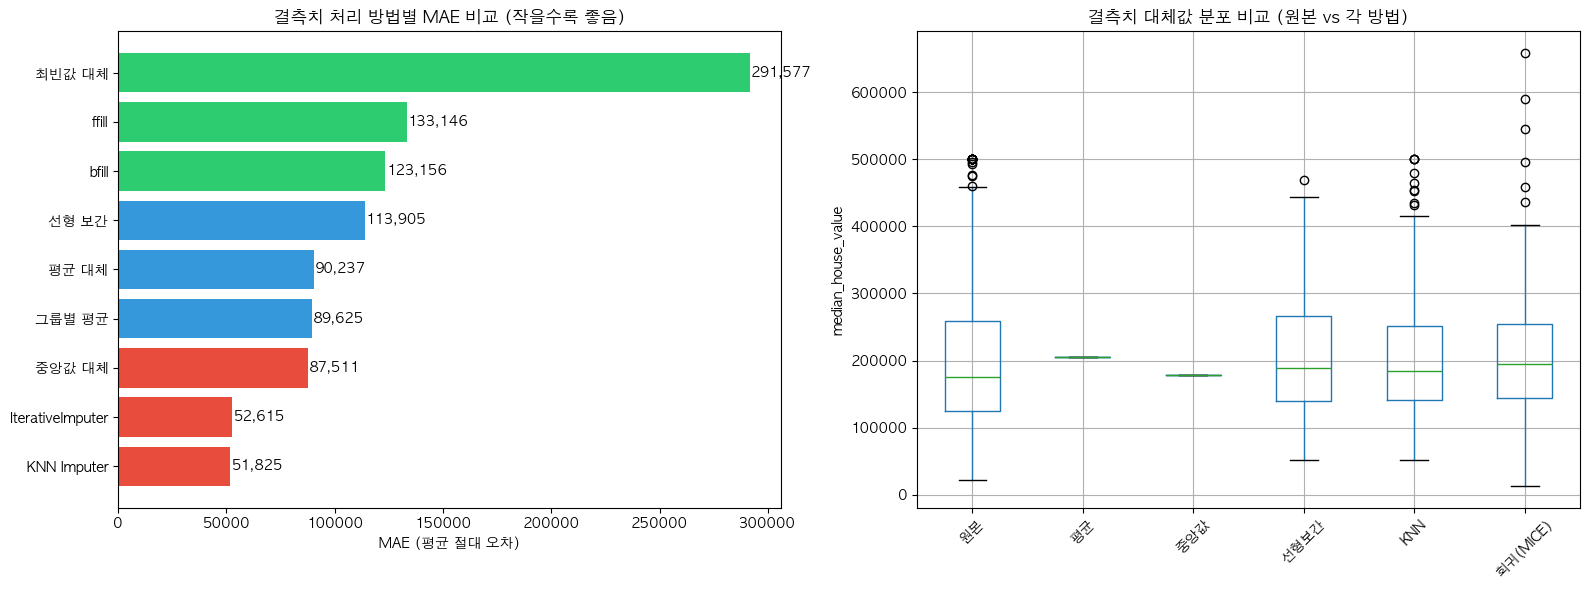


※ 결론 요약 ※
• 초급: dropna(삭제)는 간단하지만 데이터 손실 발생
• 초급: fillna(평균/중앙값)는 구현이 쉽고 빠름
• 중급: 그룹별 평균/보간법은 데이터 특성을 반영
• 고급: KNN/IterativeImputer는 다변량 관계를 활용
• 실무에서는 데이터 특성과 결측치 패턴에 맞는 방법을 선택!


In [36]:
# === MAE 비교 막대 그래프 ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 그래프 1: MAE 비교 막대 그래프
colors = ['#2ecc71' if i < 3 else '#3498db' if i < 6 else '#e74c3c'
          for i in range(len(mae_df))]
bars = axes[0].barh(mae_df['방법'], mae_df['MAE'], color=colors[::-1])
axes[0].set_xlabel('MAE (평균 절대 오차)')
axes[0].set_title('결측치 처리 방법별 MAE 비교 (작을수록 좋음)')

# 막대 위에 값 표시
for bar, val in zip(bars, mae_df['MAE']):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                f'{val:,.0f}', va='center', fontsize=10)

# 그래프 2: 각 방법별 분포 비교 (boxplot)
# 결측치였던 위치의 대체값 분포를 비교
box_data = pd.DataFrame({
    '원본': original_values.values,
    '평균': df_mean.loc[missing_indices, 'median_house_value'].values,
    '중앙값': df_median.loc[missing_indices, 'median_house_value'].values,
    '선형보간': df_linear.loc[missing_indices, 'median_house_value'].values,
    'KNN': df_knn.loc[missing_indices, 'median_house_value'].values,
    '회귀(MICE)': df_iter.loc[missing_indices, 'median_house_value'].values,
})

box_data.boxplot(ax=axes[1], rot=45)
axes[1].set_title('결측치 대체값 분포 비교 (원본 vs 각 방법)')
axes[1].set_ylabel('median_house_value')

plt.tight_layout()
plt.show()

print()
print("=" * 60)
print("※ 결론 요약 ※")
print("=" * 60)
print("• 초급: dropna(삭제)는 간단하지만 데이터 손실 발생")
print("• 초급: fillna(평균/중앙값)는 구현이 쉽고 빠름")
print("• 중급: 그룹별 평균/보간법은 데이터 특성을 반영")
print("• 고급: KNN/IterativeImputer는 다변량 관계를 활용")
print("• 실무에서는 데이터 특성과 결측치 패턴에 맞는 방법을 선택!")
print("=" * 60)